<a href="https://colab.research.google.com/github/emilyrgarman/ml3finalproject_triage/blob/main/ANN_RNN_BUILDING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ANN + RNN Model Building
RNN as a baseline for ClinicalBERT performance

In [265]:
! git clone https://github.com/emilyrgarman/ml3finalproject_triage.git

fatal: destination path 'ml3finalproject_triage' already exists and is not an empty directory.


In [266]:
import pandas as pd
import numpy as np
import random
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

SEED = 42

In [267]:
tab_data = pd.read_csv('/content/ml3finalproject_triage/train.csv')
complaints = pd.read_csv('/content/ml3finalproject_triage/chief_complaints.csv')
history = pd.read_csv('/content/ml3finalproject_triage/patient_history.csv')

In [268]:
df = tab_data.merge(complaints[['patient_id', 'chief_complaint_raw']], on='patient_id', how='left')
df = df.merge(history, on='patient_id', how='left')

Preprocessing - removing severity adjectives and descriptions that indicate triage level, augmenting data to introduce noise, removing duplicate rows, train/val/test split

In [270]:
SEVERITY_WORDS = ['mild', 'moderate', 'severe',
                  'critical', 'minor', 'major', 'actively',
                  'intermittent', 'in known patient']

def clean_complaint(x):
    x = re.split(r'[,，]', x)[0]
    return re.sub('|'.join(SEVERITY_WORDS), '', x, flags=re.IGNORECASE).strip()

df['cc_stripped'] = df['chief_complaint_raw'].apply(clean_complaint)

In [271]:
# ── Columns ────────────────────────────────────────────────
NUMERIC_COLS = ['age', 'num_active_medications', 'num_comorbidities',
                'systolic_bp', 'diastolic_bp', 'heart_rate',
                'respiratory_rate', 'temperature_c', 'spo2',
                'gcs_total', 'pain_score', 'bmi',
                'num_prior_ed_visits_12m', 'num_prior_admissions_12m']
CATEG_COLS   = ['arrival_mode', 'sex', 'transport_origin',
                'pain_location', 'mental_status_triage']
DUMMY_COLS   = ['hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1',
                'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation',
                'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 'hx_obesity',
                'hx_depression', 'hx_anxiety', 'hx_dementia', 'hx_epilepsy',
                'hx_hypothyroidism', 'hx_hyperthyroidism', 'hx_hiv', 'hx_coagulopathy',
                'hx_immunosuppressed', 'hx_pregnant', 'hx_substance_use_disorder',
                'hx_coronary_artery_disease', 'hx_stroke_prior',
                'hx_peripheral_vascular_disease']

TARGET_COL = 'triage_acuity'
TEXT_COL   = 'cc_stripped'
TABULAR_COLS = NUMERIC_COLS + CATEG_COLS + DUMMY_COLS

# ── Deduplicate text column ───────────────────────────────
df = df.drop_duplicates(subset=[TEXT_COL])

# ── Encode categorical columns ───────────────────────────
for col in CATEG_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# ── Tabular preprocessing ────────────────────────────────
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_tab = scaler.fit_transform(imputer.fit_transform(df[TABULAR_COLS]))

# ── Labels ───────────────────────────────────────────────
y = df[TARGET_COL].values - 1  # shift 1–5 → 0–4 for CrossEntropyLoss

# ── Split into train, val, test ──────────────────────────
# stratify ensures class distribution is preserved
X_temp, X_test, y_temp, y_test, texts_temp, texts_test = train_test_split(
    X_tab, y, df[TEXT_COL].fillna('').values,
    test_size=0.1, random_state=42, stratify=y
)

X_tr, X_val, y_tr, y_val, texts_tr, texts_val = train_test_split(
    X_temp, y_temp, texts_temp,
    test_size=0.2, random_state=42, stratify=y_temp
)

# ── Verification ─────────────────────────────────────────
overlap_train_val = set(texts_tr) & set(texts_val)
overlap_train_test = set(texts_tr) & set(texts_test)
overlap_val_test = set(texts_val) & set(texts_test)

print(f"Train: {len(y_tr)} | Val: {len(y_val)} | Test: {len(y_test)}")
print(f"Overlap Train/Val: {len(overlap_train_val)}")
print(f"Overlap Train/Test: {len(overlap_train_test)}")
print(f"Overlap Val/Test: {len(overlap_val_test)}")

Train: 1414 | Val: 354 | Test: 197
Overlap Train/Val: 0
Overlap Train/Test: 0
Overlap Val/Test: 0


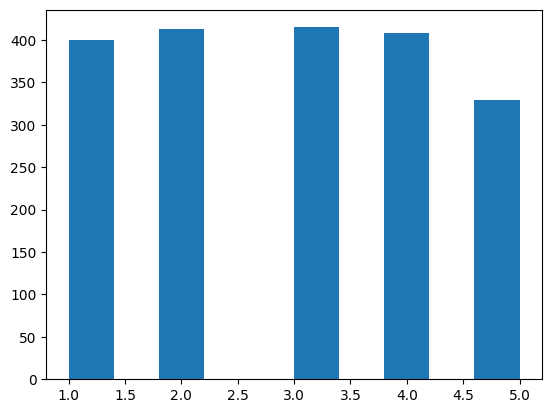

In [272]:
plt.hist(df['triage_acuity'])
plt.show()

In [273]:
# ── Clinical abbreviations ─────────────────────────────────────────
ABBREV_MAP = {
    'with': 'w/',
    'without': 'w/o',
    'history of': 'hx of',
    'complaint of': 'c/o',
    'shortness of breath': 'SOB',
    'loss of consciousness': 'LOC',
    'atrial fibrillation': 'AF',
    'diabetic ketoacidosis': 'DKA',
    'urinary tract infection': 'UTI',
    'motor vehicle accident': 'MVA',
    'chest pain': 'CP',
    'blood pressure': 'BP',
    'heart rate': 'HR',
    'nausea and vomiting': 'N&V',
    'upper respiratory tract infection': 'URTI',
    'shortness of breath': 'SOB',
    'gastrointestinal': 'GI',
    'myocardial infarction': 'MI',
    'pulmonary embolism': 'PE',
    'deep vein thrombosis': 'DVT',
    'electrocardiogram': 'ECG',
    'fracture': 'frx',
    'laceration': 'lac',
    'abdominal': 'abd',
    'bilateral': 'bil',
}

# ── Typos ──────────────────────────────────────────────────────────
TYPO_MAP = {
    'fever': ['fevre', 'fver', 'fevr'],
    'pain': ['paon', 'pian', 'pan'],
    'vomiting': ['vomitting', 'vomitng', 'vomitin'],
    'breathing': ['breathng', 'brething', 'breathin'],
    'headache': ['headach', 'headche', 'hedache'],
    'abdominal': ['abdomnal', 'abdomial', 'abdomianl'],
    'dizziness': ['dizzness', 'diziness', 'dizzines'],
    'swelling': ['sweling', 'swlling', 'sweeling'],
    'bleeding': ['bleeing', 'bleding', 'bleedin'],
    'fracture': ['fractue', 'fractrure', 'fractyre'],
    'infection': ['infecton', 'infeccion', 'infectoin'],
    'severe': ['severre', 'seveer', 'sevre'],
    'chronic': ['chronc', 'chornic', 'chonic'],
    'acute': ['acuте', 'acte', 'acut'],
    'nausea': ['nasea', 'nauseau', 'nasuea'],
    'laceration': ['laceraion', 'lacerartion', 'laceraton'],
    'palpitations': ['palpitaions', 'palpitaitons', 'palpitatons'],
    'dyspnoea': ['dyspnoea', 'dyspnea', 'dispnoea'],
    'haemorrhage': ['haemmorhage', 'heamorrhage', 'haemorrhge'],
}

def abbreviate(text, p=0.5):
    for term, abbrev in ABBREV_MAP.items():
        if term in text.lower() and random.random() < p:
            text = re.sub(term, abbrev, text, flags=re.IGNORECASE)
    return text

def add_typos(text, p=0.2):
    words = text.split()
    for i, word in enumerate(words):
        if word.lower() in TYPO_MAP and random.random() < p:
            words[i] = random.choice(TYPO_MAP[word.lower()])
    return ' '.join(words)

def augment(text):
    r = random.random()
    if r < 0.4:
        text = abbreviate(text, p=0.8)    # heavy abbreviation
    elif r < 0.7:
        text = add_typos(text, p=0.3)     # some typos
    elif r < 0.9:
        text = abbreviate(text, p=0.4)    # light abbreviation
        text = add_typos(text, p=0.1)     # plus occasional typo
    # else 10% → return text unchanged
    return text

# ── Apply to train only ────────────────────────────────────────────
aug_texts  = [augment(t) for t in texts_tr]
aug_labels = y_tr.copy()

texts_tr_aug = aug_texts.copy()
y_tr_aug     = aug_labels.copy()

Using the same ANN model as the ANN + ClinicalBERT model building notebook in order to make fair comparisons

In [274]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Model definition ───────────────────────────────────────────────
class TabularANN(nn.Module):
    def __init__(self, input_dim, num_classes=5, hidden=[128, 64], dropout=0.3):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)  # raw logits

# ── DataLoaders ────────────────────────────────────────────────────
def make_loader(X, y=None, batch_size=256, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    if y is not None:
        yt = torch.tensor(y.squeeze(), dtype=torch.long)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(Xt), batch_size=batch_size)

tr_loader  = make_loader(X_tr,  y_tr,  shuffle=True)
val_loader = make_loader(X_val, y_val)

# ── Training ───────────────────────────────────────────────────────
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS  = 30

ann       = TabularANN(input_dim=X_tr.shape[1]).to(DEVICE)
optimizer = torch.optim.AdamW(ann.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss, best_state = float('inf'), None

for epoch in range(1, EPOCHS + 1):
    ann.train()
    for Xb, yb in tr_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(ann(Xb), yb)
        loss.backward()
        optimizer.step()
    scheduler.step()

    # Validation
    ann.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            logits = ann(Xb.to(DEVICE))
            val_loss += criterion(logits, yb.to(DEVICE)).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    val_loss /= len(val_loader)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = ann.state_dict()

    if epoch % 5 == 0:
        from sklearn.metrics import f1_score
        f1 = f1_score(trues, preds, average='macro')
        print(f'Epoch {epoch:3d} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

ann.load_state_dict(best_state)
print('Training complete. Best val loss:', round(best_val_loss, 4))

# ── Get probabilities for fusion later ────────────────────────────
def get_probs(model, X):
    model.eval()
    loader = make_loader(X)
    probs  = []
    with torch.no_grad():
        for (Xb,) in loader:
            logits = model(Xb.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(probs)

ann_val_probs  = get_probs(ann, X_val)
ann_test_probs = get_probs(ann, X_test)

Epoch   5 | Val Loss: 1.0680 | Val Macro-F1: 0.5398
Epoch  10 | Val Loss: 0.8902 | Val Macro-F1: 0.6205
Epoch  15 | Val Loss: 0.7798 | Val Macro-F1: 0.6844
Epoch  20 | Val Loss: 0.7172 | Val Macro-F1: 0.7272
Epoch  25 | Val Loss: 0.6929 | Val Macro-F1: 0.7239
Epoch  30 | Val Loss: 0.6872 | Val Macro-F1: 0.7272
Training complete. Best val loss: 0.6872


Building the RNN baseline model using LSTM (since clinical notes can have multiple notes regarding patient condition, it may be useful to use a model that can account for long term dependencies)

In [275]:
from collections import Counter

MAX_VOCAB = 20000
MAX_LEN   = 10

def tokenize(text):
    return text.lower().split()

# Build vocab from augmented training data
counter = Counter()
for text in texts_tr_aug:
    counter.update(tokenize(text))

vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(MAX_VOCAB))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

def encode(text):
    tokens = tokenize(text)
    ids = [vocab.get(t, 1) for t in tokens][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids += [0] * (MAX_LEN - len(ids))
    return ids

X_text_tr  = np.array([encode(t) for t in texts_tr_aug])
X_text_val= np.array([encode(t) for t in texts_val])
X_text_test= np.array([encode(t) for t in texts_test])

In [276]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)                # this is the batch size, sequence length, and embedding size
        _, (h, _) = self.lstm(emb)             # this is final hidden state
        out = self.fc(self.dropout(h[-1]))     # this is the batch size and the number of levels in target variable
        return out, h[-1]                      # this is returning the embeddings for fusion

In [277]:
def make_text_loader(X, y=None, batch_size=128, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.long)
    if y is not None:
        yt = torch.tensor(y.squeeze(), dtype=torch.long)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(Xt), batch_size=batch_size)

tr_text_loader  = make_text_loader(X_text_tr,  y_tr_aug, shuffle=True)
val_text_loader = make_text_loader(X_text_val, y_val)

In [278]:
import torch
from sklearn.metrics import f1_score

# RNN, optimizer, and loss (weights already defined)
rnn = RNNClassifier(vocab_size=len(vocab)).to(DEVICE)
optimizer = torch.optim.Adam(rnn.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))

# Early stopping parameters
max_epochs = 50          # large max number of epochs
patience  = 5            # stop if no improvement for this many epochs
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

train_losses, val_losses = [], []

for epoch in range(max_epochs):
    # -------------------------
    # Training
    # -------------------------
    rnn.train()
    total_loss = 0
    for Xb, yb in tr_text_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits, _ = rnn(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(tr_text_loader)
    train_losses.append(avg_train_loss)

    # -------------------------
    # Validation
    # -------------------------
    rnn.eval()
    val_loss = 0
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in val_text_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits, _ = rnn(Xb)
            loss = criterion(logits, yb)
            val_loss += loss.item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.cpu().numpy())

    avg_val_loss = val_loss / len(val_text_loader)
    val_losses.append(avg_val_loss)
    f1 = f1_score(trues, preds, average='macro')

    print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {f1:.4f}")

    # -------------------------
    # Early stopping check
    # -------------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = rnn.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

# Restore the best model weights
rnn.load_state_dict(best_state)
print(f"Training finished. Best val loss: {best_val_loss:.4f}")

Epoch  1 | Train Loss: 1.6130 | Val Loss: 1.6054 | Val F1: 0.0793
Epoch  2 | Train Loss: 1.5968 | Val Loss: 1.5985 | Val F1: 0.1940
Epoch  3 | Train Loss: 1.5904 | Val Loss: 1.5837 | Val F1: 0.1481
Epoch  4 | Train Loss: 1.5559 | Val Loss: 1.5494 | Val F1: 0.1890
Epoch  5 | Train Loss: 1.4982 | Val Loss: 1.4519 | Val F1: 0.2763
Epoch  6 | Train Loss: 1.3755 | Val Loss: 1.3092 | Val F1: 0.4052
Epoch  7 | Train Loss: 1.2096 | Val Loss: 1.1914 | Val F1: 0.4562
Epoch  8 | Train Loss: 1.0799 | Val Loss: 1.0562 | Val F1: 0.5545
Epoch  9 | Train Loss: 0.9337 | Val Loss: 0.9238 | Val F1: 0.5873
Epoch 10 | Train Loss: 0.7835 | Val Loss: 0.7624 | Val F1: 0.6945
Epoch 11 | Train Loss: 0.6281 | Val Loss: 0.6435 | Val F1: 0.7612
Epoch 12 | Train Loss: 0.5003 | Val Loss: 0.5847 | Val F1: 0.7784
Epoch 13 | Train Loss: 0.3925 | Val Loss: 0.5288 | Val F1: 0.8214
Epoch 14 | Train Loss: 0.3087 | Val Loss: 0.4583 | Val F1: 0.8757
Epoch 15 | Train Loss: 0.2386 | Val Loss: 0.4227 | Val F1: 0.9062
Epoch 16 |

RNN Loss Curve

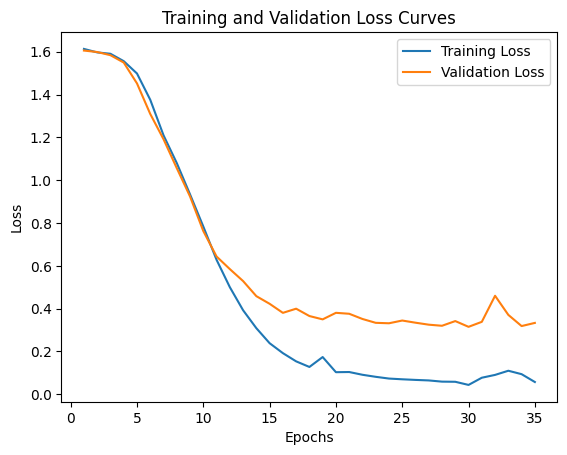

In [279]:
import matplotlib.pyplot as plt
def plot_losses(train_losses, val_losses):
  # plotting the loss curve
  epochs = range(1, len(train_losses) + 1)
  plt.plot(epochs, train_losses, label='Training Loss')
  plt.plot(epochs, val_losses, label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.title('Training and Validation Loss Curves')

  plt.show()

plot_losses(train_losses, val_losses)


Fusion - Late and Early

In [280]:
def get_rnn_outputs(model, X):
    model.eval()
    loader = make_text_loader(X)
    probs, embs = [], []
    with torch.no_grad():
        for (Xb,) in loader:
            logits, h = model(Xb.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            embs.append(h.cpu().numpy())
    return np.vstack(probs), np.vstack(embs)

X_text_tr_fusion  = np.array([encode(t) for t in texts_tr])
rnn_tr_probs,  rnn_tr_embs  = get_rnn_outputs(rnn, X_text_tr_fusion)
rnn_val_probs,  rnn_val_embs  = get_rnn_outputs(rnn, X_text_val)
rnn_test_probs, rnn_test_embs = get_rnn_outputs(rnn, X_text_test)

In [281]:
# Late Fusion - probability averaging
late_val_probs = (ann_val_probs + rnn_val_probs) / 2
late_test_probs = (ann_test_probs + rnn_test_probs) / 2

late_val_preds = late_val_probs.argmax(axis=1)
late_test_preds = late_test_probs.argmax(axis=1)

In [282]:
# Building the early fusion model
early_tr_X   = np.concatenate([rnn_tr_embs,  X_tr], axis=1)
early_val_X  = np.concatenate([rnn_val_embs,  X_val], axis=1)
early_test_X = np.concatenate([rnn_test_embs, X_test], axis=1)

INPUT_DIM = early_tr_X.shape[1]

# Using the same early fusion model definition as in ANN + ClinicalBERT notebook
class EarlyFusionHead(nn.Module):
    def __init__(self, input_dim, num_classes=5, hidden=[256, 128], dropout=0.3):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

fusion_head = EarlyFusionHead(input_dim=INPUT_DIM).to(DEVICE)

ef_tr_loader  = make_loader(early_tr_X,  y_tr,  shuffle=True)
ef_val_loader = make_loader(early_val_X, y_val)

# Defining the training loop
EPOCHS_EF = 20
optimizer_ef  = torch.optim.AdamW(fusion_head.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_ef  = nn.CrossEntropyLoss()
scheduler_ef  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ef, T_max=EPOCHS_EF)

best_val_loss_ef, best_state_ef = float('inf'), None

for epoch in range(1, EPOCHS_EF + 1):
    fusion_head.train()
    for Xb, yb in ef_tr_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer_ef.zero_grad()
        loss = criterion_ef(fusion_head(Xb), yb)
        loss.backward()
        optimizer_ef.step()
    scheduler_ef.step()

    # Validation
    fusion_head.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for Xb, yb in ef_val_loader:
            logits = fusion_head(Xb.to(DEVICE))
            val_loss += criterion_ef(logits, yb.to(DEVICE)).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    val_loss /= len(ef_val_loader)
    if val_loss < best_val_loss_ef:
        best_val_loss_ef = val_loss
        best_state_ef    = fusion_head.state_dict()

    if epoch % 5 == 0:
        f1 = f1_score(trues, preds, average='macro')
        print(f'Epoch {epoch:3d} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

fusion_head.load_state_dict(best_state_ef)
print('Best val loss:', round(best_val_loss_ef, 4))

# Getting early fusion predictions
ef_val_preds  = fusion_head(torch.tensor(early_val_X,  dtype=torch.float32).to(DEVICE))
ef_test_preds = fusion_head(torch.tensor(early_test_X, dtype=torch.float32).to(DEVICE))

ef_val_preds  = ef_val_preds.argmax(1).cpu().numpy()
ef_test_preds = ef_test_preds.argmax(1).cpu().numpy()

Epoch   5 | Val Loss: 0.2095 | Val Macro-F1: 0.9575
Epoch  10 | Val Loss: 0.2045 | Val Macro-F1: 0.9603
Epoch  15 | Val Loss: 0.2043 | Val Macro-F1: 0.9603
Epoch  20 | Val Loss: 0.2037 | Val Macro-F1: 0.9603
Best val loss: 0.2024


Results across models on test set

In [283]:
for name, p in [('ANN only',      ann_test_probs.argmax(1)),
                ('RNN only',     rnn_test_probs.argmax(1)),
                ('Late Fusion',   late_test_preds),
                ('Early Fusion',  ef_test_preds)]:
    f1 = f1_score(y_test.squeeze(), p, average='macro')
    print(f'{name:<20} Macro-F1: {f1:.4f}')

ANN only             Macro-F1: 0.6918
RNN only             Macro-F1: 0.9152
Late Fusion          Macro-F1: 0.9204
Early Fusion         Macro-F1: 0.9302


Cost matrix: cost[true][pred] — penalizes by distance between acuity levels

In [284]:
cost_matrix = np.array([[0, 1, 2, 3, 4],
                         [1, 0, 1, 2, 3],
                         [2, 1, 0, 1, 2],
                         [3, 2, 1, 0, 1],
                         [4, 3, 2, 1, 0]])

def cost_sensitive_score(y_true, y_pred, cost_matrix):
    total_cost = sum(cost_matrix[t][p] for t, p in zip(y_true, y_pred))
    # normalize by worst possible cost
    worst_cost = sum(cost_matrix[t].max() for t in y_true)
    return 1 - (total_cost / worst_cost)  # higher is better

score = cost_sensitive_score(y_test.squeeze(), late_test_preds, cost_matrix)
print(f'Cost-sensitive score: {score:.4f}')

Cost-sensitive score: 0.9662


Confusion Matrix

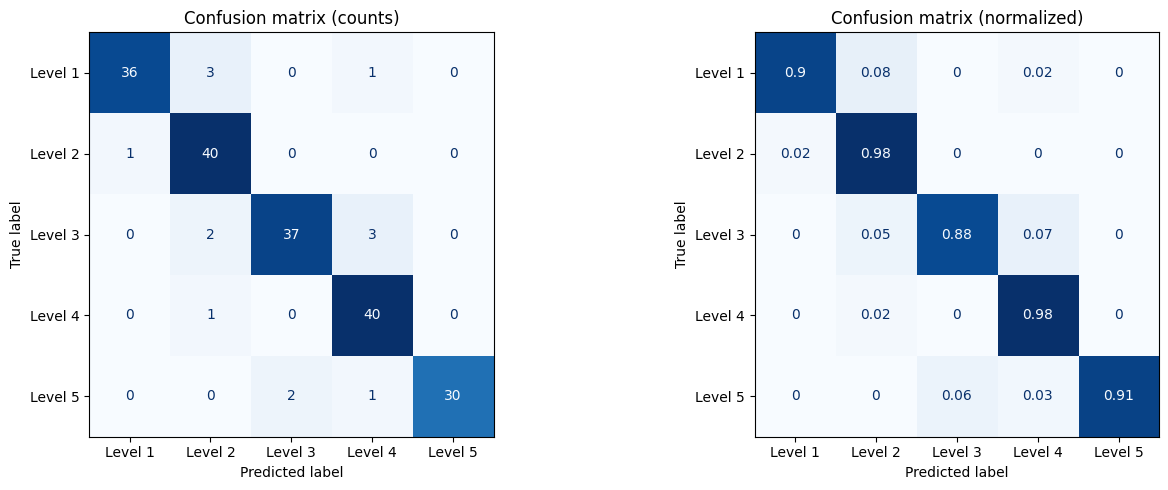

In [285]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

CLASS_NAMES = ['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']

cm = confusion_matrix(y_test, ef_test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalize

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (counts)')

# Normalized (easier to compare across class sizes)
disp_norm = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion matrix (normalized)')

plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150)
plt.show()